In [1]:
import numpy as np
import pandas as pd
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
# --- Load price data ---
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

# --- Load universe trading days ---
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(
    excelFile=universeFilePath,
    sheetName='Sheet1',
    startDate=closeDf.first_valid_index()
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [3]:
# --- Add weekly grouping ---
allTradingDatesDf["YearWeek"] = allTradingDatesDf["Date"].dt.strftime("%Y-%U")

# --- Find the last trading day of each week ---
weeklyEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby("YearWeek")["Date"].idxmax()]
weeklyEndDatesDf.sort_values(by="Date", inplace=True)

# Read the Excel file
rebal_df = pd.read_excel(r'D:\Linear Model\data\RSI\Final\NSEI\W_allRebal.xlsx')

# Make sure the 'Date' column is datetime type
rebal_df['Date'] = pd.to_datetime(rebal_df['Date'])

# --- Define weekly rebalancing period: Jan 2020 → last available trading day ---
start_date = pd.Timestamp("2020-01-01")
end_date = closeMergedDf.index.max()  # last available date from your price data

# Filter the weekly rebalancing dates within this window
weekly_rebal_dates = weeklyEndDatesDf[
    (weeklyEndDatesDf["Date"] >= start_date) & (weeklyEndDatesDf["Date"] <= end_date)
]["Date"].tolist()

rebalDates = rebal_df.loc[(rebal_df['Date'] >= start_date) & (rebal_df['Date']<= end_date), 'Date'].tolist()

# Convert to simple date objects
#rebalDates = [d.date() for d in weekly_rebal_dates]

print(f"Total weekly rebalancing dates: {len(rebalDates)}")
print("First 5 rebal dates:", rebalDates[:5])
print("Last 5 rebal dates:", rebalDates[-5:])


Total weekly rebalancing dates: 299
First 5 rebal dates: [Timestamp('2020-01-03 00:00:00'), Timestamp('2020-01-10 00:00:00'), Timestamp('2020-01-17 00:00:00'), Timestamp('2020-01-24 00:00:00'), Timestamp('2020-02-01 00:00:00')]
Last 5 rebal dates: [Timestamp('2025-08-22 00:00:00'), Timestamp('2025-08-29 00:00:00'), Timestamp('2025-09-05 00:00:00'), Timestamp('2025-09-12 00:00:00'), Timestamp('2025-09-19 00:00:00')]


In [4]:
returns = closeMergedDf.pct_change().dropna()
realized_var = returns ** 2  # daily realized variance

# Replace price series with realized variance
rvDf = realized_var.rename(columns={realized_var.columns[0]: 'RV'})  # single column for matching

In [5]:
window_size = 45  # lookback window for matching
indexLists = [0, 1, 2, 3, 4]  # indices to plot
top_regimes = []

for i, rebalDate in enumerate(rebalDates):
    print(f"\nProcessing rebal date: {rebalDate}")

    # --- Match regimes on realized variance instead of price
    sim = mk.Match(rvDf, rebalDate, windowSize=window_size, threshold=0.50)
    reg = sim.getRegime()
    if reg.empty:
        print("No matching regimes found. Skipping this date.")
        continue

    # --- Keep top 5 motifs
    top5 = reg.head(5).copy()
    top5["RebalDate"] = rebalDate
    top_regimes.append(top5)

    # # --- Optional: plot z-scored realized variance motifs
    # plt.figure(figsize=(24, 6))
    # ax = plt.gca()
    # for idx in range(min(5, len(top5))):
    #     ax.plot(
    #         stats.zscore(rvDf.loc[top5.iloc[idx].start:top5.iloc[idx].end].values),
    #         label=f"{top5.iloc[idx].start} to {top5.iloc[idx].end}"
    #     )
    # ax.legend()
    # plt.title(f"Top 5 RV-Matched Regimes for {rebalDate}")
    # plt.show()

top_regimes_df = pd.concat(top_regimes, ignore_index=True)



Processing rebal date: 2020-01-03 00:00:00

Processing rebal date: 2020-01-10 00:00:00

Processing rebal date: 2020-01-17 00:00:00

Processing rebal date: 2020-01-24 00:00:00

Processing rebal date: 2020-02-01 00:00:00

Processing rebal date: 2020-02-07 00:00:00

Processing rebal date: 2020-02-14 00:00:00

Processing rebal date: 2020-02-20 00:00:00

Processing rebal date: 2020-02-28 00:00:00

Processing rebal date: 2020-03-06 00:00:00

Processing rebal date: 2020-03-13 00:00:00

Processing rebal date: 2020-03-20 00:00:00

Processing rebal date: 2020-03-27 00:00:00

Processing rebal date: 2020-04-03 00:00:00

Processing rebal date: 2020-04-09 00:00:00

Processing rebal date: 2020-04-17 00:00:00

Processing rebal date: 2020-04-24 00:00:00

Processing rebal date: 2020-04-30 00:00:00

Processing rebal date: 2020-05-08 00:00:00

Processing rebal date: 2020-05-15 00:00:00

Processing rebal date: 2020-05-22 00:00:00

Processing rebal date: 2020-05-29 00:00:00

Processing rebal date: 2020-06-

In [6]:
top_regimes_df

,idx,start,end,dp,RebalDate
0,3405,2009-06-25,2009-08-27,5.571648,2020-01-03
1,4966,2015-10-06,2015-12-11,5.810047,2020-01-03
2,2747,2006-10-20,2006-12-26,5.826170,2020-01-03
3,1204,2000-09-04,2000-11-07,5.841555,2020-01-03
4,4468,2013-09-26,2013-12-03,5.915630,2020-01-03
...,...,...,...,...,...
1488,327,1997-02-25,1997-05-07,6.177310,2025-09-19
1489,2249,2004-10-27,2004-12-31,6.362003,2025-09-19
1490,6918,2023-08-24,2023-10-31,6.423114,2025-09-19
1491,2923,2007-07-09,2007-09-11,6.552508,2025-09-19


In [7]:
top_regimes_df.isna().sum()

idx          0
start        0
end          0
dp           0
RebalDate    0
dtype: int64

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# --- Ensure datetimes
closeMergedDf = closeMergedDf.copy()
closeMergedDf.index = pd.to_datetime(closeMergedDf.index)

top_regimes_df["start"] = pd.to_datetime(top_regimes_df["start"])
top_regimes_df["end"] = pd.to_datetime(top_regimes_df["end"])

# --- Prepare columns for post-motif stats
stats_cols = ["MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]
for col in stats_cols:
    top_regimes_df[col] = np.nan

# --- Loop through motifs
for idx, row in top_regimes_df.iterrows():
    end_date = row["end"]

    # Get calendar 1-month window after motif end
    next_month_end = end_date + pd.DateOffset(months=1)

    # Get data within that window
    mask = (closeMergedDf.index > end_date) & (closeMergedDf.index <= next_month_end)
    next_month_prices = closeMergedDf.loc[mask].iloc[:, 0]  # first column

    if len(next_month_prices) < 5:
        continue  # skip if not enough data

    # Compute daily returns
    returns = next_month_prices.pct_change().dropna()

    # --- Calculate stats ---
    mean_ret = returns.mean()
    vol = returns.std()  # daily volatility
    realized_vol = np.sum(returns ** 2)
    skew_val = skew(returns)
    kurt_val = kurtosis(returns, fisher=True)  # Fisher=True → 0 for normal dist.

    # Store results
    top_regimes_df.at[idx, "MeanRet_1M"] = mean_ret
    top_regimes_df.at[idx, "Vol_1M"] = vol
    top_regimes_df.at[idx, "RealizedVol_1M"] = realized_vol
    top_regimes_df.at[idx, "Skew_1M"] = skew_val
    top_regimes_df.at[idx, "Kurt_1M"] = kurt_val

# --- Inspect result
print(top_regimes_df[
          ["RebalDate", "start", "end", "MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]].head())

# --- Optional: Save for later analysis
#top_regimes_df.to_csv("top5_matched_regimes_with_post_stats.csv", index=False)
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# --- Ensure datetimes
closeMergedDf = closeMergedDf.copy()
closeMergedDf.index = pd.to_datetime(closeMergedDf.index)

top_regimes_df["start"] = pd.to_datetime(top_regimes_df["start"])
top_regimes_df["end"] = pd.to_datetime(top_regimes_df["end"])

# --- Prepare columns for post-motif stats
stats_cols = ["MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]
for col in stats_cols:
    top_regimes_df[col] = np.nan

# --- Loop through motifs
for idx, row in top_regimes_df.iterrows():
    end_date = row["end"]

    # Get calendar 1-month window after motif end
    next_month_end = end_date + pd.DateOffset(months=1)

    # Get data within that window
    mask = (closeMergedDf.index > end_date) & (closeMergedDf.index <= next_month_end)
    next_month_prices = closeMergedDf.loc[mask].iloc[:, 0]  # first column

    if len(next_month_prices) < 5:
        continue  # skip if not enough data

    # Compute daily returns
    returns = next_month_prices.pct_change().dropna()

    # --- Calculate stats ---
    mean_ret = returns.mean()
    vol = returns.std()  # daily volatility
    realized_vol = np.sum(returns ** 2)
    skew_val = skew(returns)
    kurt_val = kurtosis(returns, fisher=True)  # Fisher=True → 0 for normal dist.

    # Store results
    top_regimes_df.at[idx, "MeanRet_1M"] = mean_ret
    top_regimes_df.at[idx, "Vol_1M"] = vol
    top_regimes_df.at[idx, "RealizedVol_1M"] = realized_vol
    top_regimes_df.at[idx, "Skew_1M"] = skew_val
    top_regimes_df.at[idx, "Kurt_1M"] = kurt_val

# --- Inspect result
print(top_regimes_df[
          ["RebalDate", "start", "end", "MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]].head())

# --- Optional: Save for later analysis
#top_regimes_df.to_csv("top5_matched_regimes_with_post_stats.csv", index=False)


   RebalDate      start        end  MeanRet_1M    Vol_1M  RealizedVol_1M  \
0 2020-01-03 2009-06-25 2009-08-27    0.002511  0.009960        0.001906   
1 2020-01-03 2015-10-06 2015-12-11   -0.000550  0.009818        0.001741   
2 2020-01-03 2006-10-20 2006-12-26    0.002196  0.011102        0.002438   
3 2020-01-03 2000-09-04 2000-11-07    0.001405  0.012988        0.003415   
4 2020-01-03 2013-09-26 2013-12-03    0.000422  0.008680        0.001511   

    Skew_1M   Kurt_1M  
0  0.404394 -0.529223  
1 -0.901962  0.119861  
2  0.686246  0.178167  
3 -0.125455  0.318058  
4  0.534434 -0.463018  
   RebalDate      start        end  MeanRet_1M    Vol_1M  RealizedVol_1M  \
0 2020-01-03 2009-06-25 2009-08-27    0.002511  0.009960        0.001906   
1 2020-01-03 2015-10-06 2015-12-11   -0.000550  0.009818        0.001741   
2 2020-01-03 2006-10-20 2006-12-26    0.002196  0.011102        0.002438   
3 2020-01-03 2000-09-04 2000-11-07    0.001405  0.012988        0.003415   
4 2020-01-03 2013-0

In [9]:
# Ensure dp column exists
assert "dp" in top_regimes_df.columns, "Missing 'dp' column — required for weighting."

# Function to compute weighted average where smaller dp → higher weight
def weighted_avg(df, value_col, weight_col="dp"):
    # Drop NaN values
    df = df[[value_col, weight_col]].dropna()
    if df.empty:
        return np.nan

    # Compute inverse-distance weights
    inv_w = 1 / df[weight_col]
    weights = inv_w / inv_w.sum()

    return np.sum(df[value_col] * weights)

# --- Compute weighted averages for each rebal date
agg_list = []
for rebal, group in top_regimes_df.groupby("RebalDate"):
    result = {"RebalDate": rebal}

    # Weighted averages (you can include more metrics)
    result["WgtVol_1M"] = weighted_avg(group, "Vol_1M")
    result["WgtMeanRet_1M"] = weighted_avg(group, "MeanRet_1M")
    result["WgtRealizedVol_1M"] = weighted_avg(group, "RealizedVol_1M")
    result["WgtSkew_1M"] = weighted_avg(group, "Skew_1M")
    result["WgtKurt_1M"] = weighted_avg(group, "Kurt_1M")

    agg_list.append(result)

# Combine into DataFrame
rebal_weighted_stats = pd.DataFrame(agg_list).sort_values("RebalDate")

# --- Inspect results
print(rebal_weighted_stats.head())

# --- Optional: Save to file
#rebal_weighted_stats.to_csv("rebal_weighted_volatility.csv", index=False)


   RebalDate  WgtVol_1M  WgtMeanRet_1M  WgtRealizedVol_1M  WgtSkew_1M  \
0 2020-01-03   0.010508       0.001210           0.002201    0.120436   
1 2020-01-10   0.014537       0.002962           0.004838   -0.083393   
2 2020-01-17   0.015742       0.001429           0.005251    0.215880   
3 2020-01-24   0.016317       0.002104           0.006281   -0.001065   
4 2020-02-01   0.010688      -0.000086           0.002446   -0.094758   

   WgtKurt_1M  
0   -0.078286  
1   -0.634139  
2   -0.515726  
3    0.264904  
4   -0.558036  


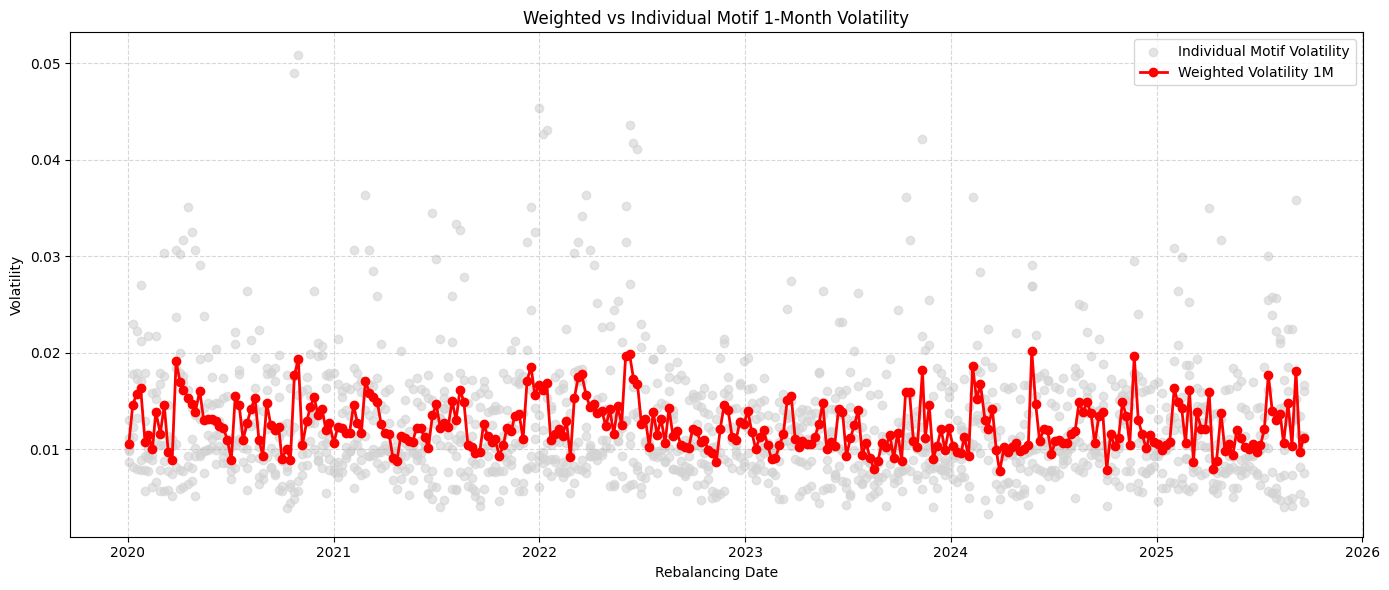

In [10]:
import matplotlib.pyplot as plt

# Ensure dates are datetime and sorted
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])
rebal_weighted_stats["RebalDate"] = pd.to_datetime(rebal_weighted_stats["RebalDate"])
top_regimes_df = top_regimes_df.sort_values("RebalDate")
rebal_weighted_stats = rebal_weighted_stats.sort_values("RebalDate")

plt.figure(figsize=(14, 6))

# Plot individual motif volatilities as semi-transparent points
plt.scatter(
    top_regimes_df["RebalDate"],
    top_regimes_df["Vol_1M"],
    color='lightgray',
    alpha=0.6,
    label="Individual Motif Volatility"
)

# Plot weighted volatility as solid line
plt.plot(
    rebal_weighted_stats["RebalDate"],
    rebal_weighted_stats["WgtVol_1M"],
    color='red',
    marker='o',
    linewidth=2,
    label="Weighted Volatility 1M"
)

plt.title("Weighted vs Individual Motif 1-Month Volatility")
plt.xlabel("Rebalancing Date")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd

def robust_nw_forecast(df, value_col, distance_col="dp", eta_factor=0.2):
    """
    Compute Nadaraya-Watson forecast with automatically scaled bandwidth.

    Parameters:
    - df: DataFrame with value_col (target) and distance_col (dp)
    - value_col: column to forecast (e.g., Vol_1M)
    - distance_col: column representing distance (smaller = closer)
    - eta_factor: fraction of mean distance to use as bandwidth (eta = mean(dp) * eta_factor)

    Returns:
    - Weighted forecast (float)
    """
    df = df[[value_col, distance_col]].dropna()
    if df.empty:
        return np.nan

    # Automatic bandwidth scaling
    mean_dp = df[distance_col].mean()
    eta = mean_dp * eta_factor
    if eta <= 0:
        eta = 1e-5  # safeguard

    # Gaussian kernel weights
    weights = np.exp(-(df[distance_col] ** 2) / (2 * eta**2))
    weights /= weights.sum()

    # Weighted forecast
    forecast = np.sum(weights * df[value_col])
    return forecast

# --- Compute NW forecast per rebal date ---
nw_forecasts = []

for rebal, group in top_regimes_df.groupby("RebalDate"):
    forecast = robust_nw_forecast(group, value_col="Vol_1M", distance_col="dp", eta_factor=0.2)
    nw_forecasts.append({"RebalDate": rebal, "NW_Vol_1M": forecast})

nw_forecast_df = pd.DataFrame(nw_forecasts).sort_values("RebalDate")

print(nw_forecast_df.head())


   RebalDate  NW_Vol_1M
0 2020-01-03   0.010406
1 2020-01-10   0.016642
2 2020-01-17   0.017228
3 2020-01-24   0.014492
4 2020-02-01   0.009558


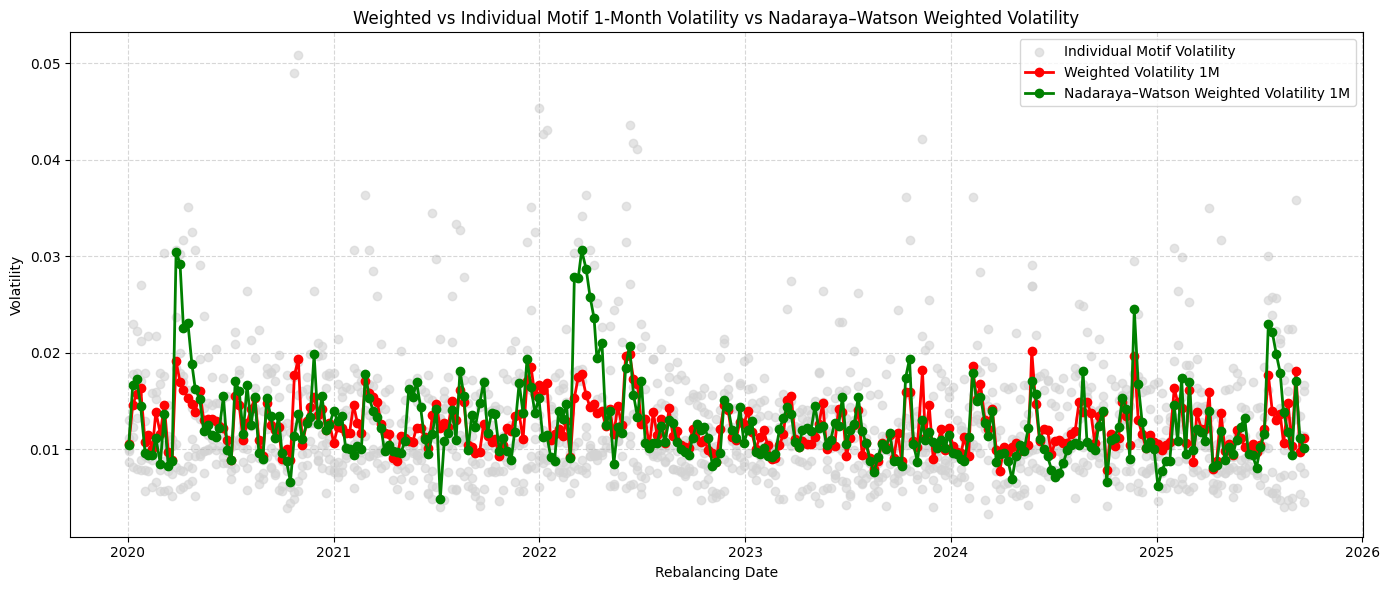

In [12]:
# Ensure dates are datetime and sorted
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])
rebal_weighted_stats["RebalDate"] = pd.to_datetime(rebal_weighted_stats["RebalDate"])
top_regimes_df = top_regimes_df.sort_values("RebalDate")
rebal_weighted_stats = rebal_weighted_stats.sort_values("RebalDate")

plt.figure(figsize=(14,6))

# Plot individual motif volatilities as semi-transparent points
plt.scatter(
    top_regimes_df["RebalDate"],
    top_regimes_df["Vol_1M"],
    color='lightgray',
    alpha=0.6,
    label="Individual Motif Volatility"
)

# Plot weighted volatility as solid line
plt.plot(
    rebal_weighted_stats["RebalDate"],
    rebal_weighted_stats["WgtVol_1M"],
    color='red',
    marker='o',
    linewidth=2,
    label="Weighted Volatility 1M"
)

plt.plot(
    nw_forecast_df["RebalDate"],
    nw_forecast_df["NW_Vol_1M"],
    color='green',
    marker='o',
    linewidth=2,
    label="Nadaraya–Watson Weighted Volatility 1M"
)

plt.title("Weighted vs Individual Motif 1-Month Volatility vs Nadaraya–Watson Weighted Volatility")
plt.xlabel("Rebalancing Date")
plt.xlabel("Rebalancing Date")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# Function to compute realized 1-month volatility after a date
def realized_vol(df, date, window='1M', price_col=0):
    """
    df: price DataFrame (datetime index)
    date: reference date (datetime)
    window: pandas offset alias for 1 month ('1M')
    price_col: column index of prices
    """
    end_date = date + pd.DateOffset(months=1)
    mask = (df.index > date) & (df.index <= end_date)
    prices = df.loc[mask].iloc[:, price_col]
    if len(prices) < 2:
        return np.nan
    returns = prices.pct_change().dropna()
    return returns.std()  # daily volatility; multiply by sqrt(252) for annualized

# Ensure RebalDate column is datetime
nw_forecast_df["RebalDate"] = pd.to_datetime(nw_forecast_df["RebalDate"])
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])

# Compute observed volatility per rebal date
observed_vols = []
for date in nw_forecast_df["RebalDate"]:
    obs_vol = realized_vol(closeMergedDf, date, window='1M', price_col=0)
    observed_vols.append(obs_vol)

nw_forecast_df["Observed_Vol_1M"] = observed_vols

# Inspect
print(nw_forecast_df.head())


   RebalDate  NW_Vol_1M  Observed_Vol_1M
0 2020-01-03   0.010406         0.008523
1 2020-01-10   0.016642         0.009498
2 2020-01-17   0.017228         0.009656
3 2020-01-24   0.014492         0.010789
4 2020-02-01   0.009558         0.012903


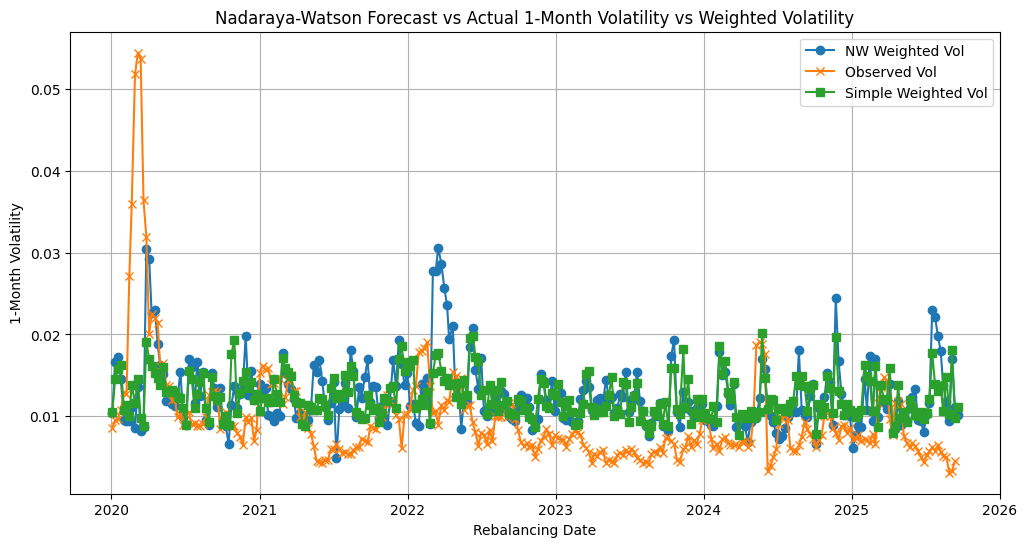

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["NW_Vol_1M"], marker='o', label="NW Weighted Vol")
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["Observed_Vol_1M"], marker='x', label="Observed Vol")
plt.plot(rebal_weighted_stats["RebalDate"],rebal_weighted_stats['WgtVol_1M'],marker='s', label="Simple Weighted Vol")

plt.xlabel("Rebalancing Date")
plt.ylabel("1-Month Volatility")
plt.title("Nadaraya-Watson Forecast vs Actual 1-Month Volatility vs Weighted Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
correlation_nw = nw_forecast_df["NW_Vol_1M"].corr(nw_forecast_df["Observed_Vol_1M"])
correlation = rebal_weighted_stats['WgtVol_1M'].corr(nw_forecast_df["Observed_Vol_1M"])
print(f"Correlation between simple forecast and actual volatility: {correlation:.4f}")
print(f"Correlation between NW forecast and actual volatility: {correlation_nw:.4f}")

Correlation between simple forecast and actual volatility: 0.1143
Correlation between NW forecast and actual volatility: 0.1031


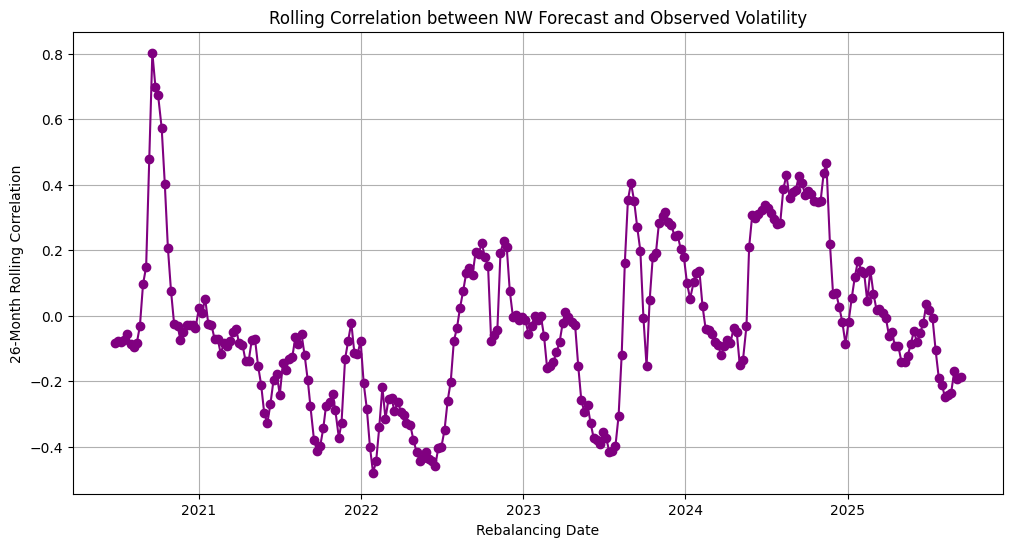

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure RebalDate is datetime and sorted
nw_forecast_df["RebalDate"] = pd.to_datetime(nw_forecast_df["RebalDate"])
nw_forecast_df = nw_forecast_df.sort_values("RebalDate").reset_index(drop=True)

# Set rolling window (e.g., 3 or 6 months)
rolling_window = 26  # 3-month rolling correlation

# Compute rolling correlation
nw_forecast_df["RollingCorr"] = nw_forecast_df["NW_Vol_1M"].rolling(rolling_window).corr(
    nw_forecast_df["Observed_Vol_1M"]
)

# Plot rolling correlation
plt.figure(figsize=(12, 6))
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["RollingCorr"], marker='o', color='purple')
plt.xlabel("Rebalancing Date")
plt.ylabel(f"{rolling_window}-Month Rolling Correlation")
plt.title(f"Rolling Correlation between NW Forecast and Observed Volatility")
plt.grid(True)
plt.show()


In [17]:
# Get best matching motif (smallest dp) per rebal date
best_motif_df = top_regimes_df.loc[top_regimes_df.groupby("RebalDate")["dp"].idxmin()]

# Keep only relevant columns
best_motif_df = best_motif_df[["RebalDate", "Vol_1M", "dp"]].copy()
best_motif_df.rename(columns={"Vol_1M": "BestMotif_Vol_1M", "dp": "BestMotif_dp"}, inplace=True)
best_motif_df

,RebalDate,BestMotif_Vol_1M,BestMotif_dp
0,2020-01-03,0.009960,5.571648
5,2020-01-10,0.023006,4.504538
10,2020-01-17,0.022250,4.846989
15,2020-01-24,0.007849,5.131183
20,2020-02-01,0.007857,4.161521
...,...,...,...
1468,2025-08-22,0.004717,5.668088
1473,2025-08-29,0.007317,6.154454
1478,2025-09-05,0.015188,6.352878
1483,2025-09-12,0.013406,6.088180


In [18]:
# Merge on RebalDate
comparison_df = best_motif_df.merge(
    nw_forecast_df[["RebalDate", "Observed_Vol_1M"]],
    on="RebalDate",
    how="left"
)

# Inspect
print(comparison_df.head())

   RebalDate  BestMotif_Vol_1M  BestMotif_dp  Observed_Vol_1M
0 2020-01-03          0.009960      5.571648         0.008523
1 2020-01-10          0.023006      4.504538         0.009498
2 2020-01-17          0.022250      4.846989         0.009656
3 2020-01-24          0.007849      5.131183         0.010789
4 2020-02-01          0.007857      4.161521         0.012903


In [19]:
# Forecast error: best motif - observed
comparison_df["Error"] = comparison_df["BestMotif_Vol_1M"] - comparison_df["Observed_Vol_1M"]
comparison_df["AbsError"] = comparison_df["Error"].abs()

# Correlation
corr_best = comparison_df["BestMotif_Vol_1M"].corr(comparison_df["Observed_Vol_1M"])
print(f"Correlation between Best Motif Vol and Observed Vol: {corr_best:.4f}")


Correlation between Best Motif Vol and Observed Vol: 0.0882


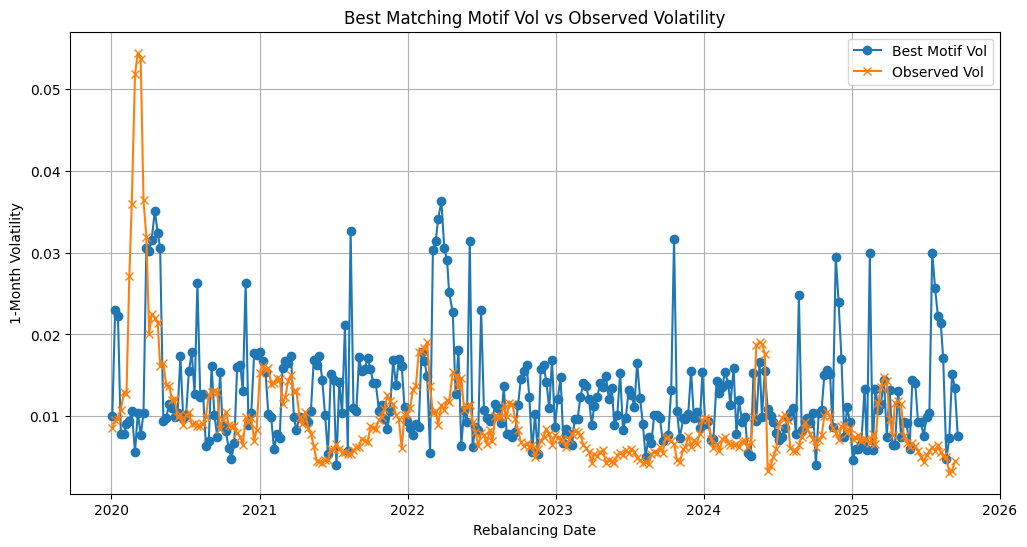

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_df["RebalDate"], comparison_df["BestMotif_Vol_1M"], marker='o', label="Best Motif Vol")
plt.plot(comparison_df["RebalDate"], comparison_df["Observed_Vol_1M"], marker='x', label="Observed Vol")
plt.xlabel("Rebalancing Date")
plt.ylabel("1-Month Volatility")
plt.title("Best Matching Motif Vol vs Observed Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
price_df = closeMergedDf.copy()
price_df['return'] = price_df['.NSEI'].pct_change()
price_df = price_df.dropna()
price_df['RealizedVol_1M'] = price_df['return'].rolling(window=30).std().dropna()
price_df = price_df.dropna()

In [22]:
# --- Define weekly rebalancing period: Jan 2020 → last available trading day ---
start_date = price_df.index.min()
end_date = price_df.index.max()  # last available date from your price data

weekly_rebal_dates = rebal_df.loc[(rebal_df['Date'] >= start_date) & (rebal_df['Date']<= end_date), 'Date'].tolist()

In [23]:
weekly_rebal_dates

[Timestamp('1995-12-15 00:00:00'),
 Timestamp('1995-12-22 00:00:00'),
 Timestamp('1995-12-29 00:00:00'),
 Timestamp('1996-01-05 00:00:00'),
 Timestamp('1996-01-12 00:00:00'),
 Timestamp('1996-01-19 00:00:00'),
 Timestamp('1996-01-25 00:00:00'),
 Timestamp('1996-02-02 00:00:00'),
 Timestamp('1996-02-09 00:00:00'),
 Timestamp('1996-02-16 00:00:00'),
 Timestamp('1996-02-23 00:00:00'),
 Timestamp('1996-03-01 00:00:00'),
 Timestamp('1996-03-08 00:00:00'),
 Timestamp('1996-03-15 00:00:00'),
 Timestamp('1996-03-22 00:00:00'),
 Timestamp('1996-03-29 00:00:00'),
 Timestamp('1996-04-04 00:00:00'),
 Timestamp('1996-04-12 00:00:00'),
 Timestamp('1996-04-19 00:00:00'),
 Timestamp('1996-04-26 00:00:00'),
 Timestamp('1996-05-03 00:00:00'),
 Timestamp('1996-05-10 00:00:00'),
 Timestamp('1996-05-17 00:00:00'),
 Timestamp('1996-05-24 00:00:00'),
 Timestamp('1996-05-31 00:00:00'),
 Timestamp('1996-06-07 00:00:00'),
 Timestamp('1996-06-14 00:00:00'),
 Timestamp('1996-06-21 00:00:00'),
 Timestamp('1996-06-

In [24]:
weekly_rebal_df = pd.DataFrame({"Date": weekly_rebal_dates})

In [25]:
monthly_rebal_dates = (
    weekly_rebal_df.loc[
        weekly_rebal_df.groupby(weekly_rebal_df["Date"].dt.to_period("M"))["Date"].idxmin()
    ].reset_index(drop=True)
)


In [26]:
monthly_rebal_dates

,Date
0,1995-12-15
1,1996-01-05
2,1996-02-02
3,1996-03-01
4,1996-04-04
...,...
353,2025-05-02
354,2025-06-06
355,2025-07-04
356,2025-08-01


In [27]:
# monthly_rebal_dates = (
#     rebal_df.set_index("Date")
#     .resample("BMS")
#     .first()
#     .index
#     .to_list()
# )
observed_vols_df = pd.DataFrame(index=monthly_rebal_dates['Date'])

In [28]:
observed_vols_df

""
Date
1995-12-15
1996-01-05
1996-02-02
1996-03-01
1996-04-04
...
2025-05-02
2025-06-06
2025-07-04


In [30]:
# Compute observed volatility per weekly rebal date
observed_vols = []
for date in monthly_rebal_dates:
    date = pd.Timestamp(date)
    obs_vol = realized_vol(price_df, date, window='1M', price_col=0)
    observed_vols.append(obs_vol)

observed_vols_df["Observed_Vol_1M"] = observed_vols
observed_vols_df = observed_vols_df.dropna()

# Inspect
print(observed_vols_df.head())

DateParseError: Unknown datetime string format, unable to parse: Date

In [ ]:
observed_vols_df.plot()
price_df['RealizedVol_1M'].plot(label='Realized Vol 1M')
plt.legend()

In [ ]:
rebal_weighted_stats = (
    rebal_weighted_stats.set_index("RebalDate")
    .resample("BMS")
    .first()
    .reset_index()
)

nw_forecast_df = (
    nw_forecast_df.set_index("RebalDate")
    .resample("BMS")
    .first()
    .reset_index()
)

In [ ]:
rebal_weighted_stats

In [ ]:
nw_forecast_df

In [ ]:
rebal_weighted_stats['Observed_Vol_1M'] = nw_forecast_df['Observed_Vol_1M']
rebal_weighted_stats = rebal_weighted_stats.dropna()
rebal_weighted_stats

In [ ]:

n_buckets = 30

# Prepare columns for buckets
nw_forecast_df["VolBucket"] = np.nan
rebal_weighted_stats["VolBucket"] = np.nan
rebal_weighted_stats["Observed_VolBucket"] = np.nan

# Loop over each rebal date
for idx, date in enumerate(rebal_weighted_stats["RebalDate"]):
    # Past-only observed vols up to this date
    past_obs_vols = observed_vols_df.loc[observed_vols_df.index <= date, "Observed_Vol_1M"]

    if len(past_obs_vols) < n_buckets:
        # Skip or assign NaN if not enough data
        continue

    # Compute bucket edges from past-only data
    bucket_edges = np.quantile(past_obs_vols, np.linspace(0, 1, n_buckets + 1))

    # Assign current predicted/weighted vol to bucket
    wgt_vol = rebal_weighted_stats.at[idx, "WgtVol_1M"]
    obs_vol = rebal_weighted_stats.at[idx, "Observed_Vol_1M"]
    nw_vol = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date, "NW_Vol_1M"].values[0]


    def assign_bucket(vol, edges):
        for i in range(len(edges) - 1):
            if edges[i] <= vol < edges[i + 1]:
                return i + 1
        if vol >= edges[-1]:
            return len(edges) - 1
        return np.nan


    rebal_weighted_stats.at[idx, "VolBucket"] = assign_bucket(wgt_vol, bucket_edges)
    rebal_weighted_stats.at[idx, "Observed_VolBucket"] = assign_bucket(obs_vol, bucket_edges)
    nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date, "VolBucket"] = assign_bucket(nw_vol, bucket_edges)

# Now each date's bucket assignment only depends on past data → no forward bias


In [ ]:
rebal_weighted_stats

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Compute edges for 30 buckets ---
n_buckets = 30
hist_vol = observed_vols_df["Observed_Vol_1M"]

bucket_edges = np.quantile(hist_vol, np.linspace(0, 1, n_buckets + 1))
print("Bucket edges:", bucket_edges)

# --- Update assign_bucket function (same as before) ---
def assign_bucket(vol, edges):
    """
    Map volatility to bucket 1..n_buckets based on edges
    """
    for i in range(len(edges) - 1):
        if edges[i] <= vol < edges[i + 1]:
            return i + 1
    # Edge case: vol == max edge
    if vol >= edges[-1]:
        return len(edges) - 1
    return np.nan

# --- Winsorize WgtVol_1M at 5th and 95th percentile ---
lower, upper = np.percentile(rebal_weighted_stats["WgtVol_1M"].dropna(), [5, 95])
rebal_weighted_stats["WgtVol_1M_Wins"] = rebal_weighted_stats["WgtVol_1M"].clip(lower, upper)

print(f"Winsorization bounds applied on WgtVol_1M: [{lower:.4f}, {upper:.4f}]")

# --- Map predicted & weighted vols to buckets ---
nw_forecast_df["VolBucket"] = nw_forecast_df["NW_Vol_1M"].apply(lambda x: assign_bucket(x, bucket_edges))
rebal_weighted_stats["VolBucket"] = rebal_weighted_stats["WgtVol_1M_Wins"].apply(lambda x: assign_bucket(x, bucket_edges))
rebal_weighted_stats["Observed_VolBucket"] = rebal_weighted_stats["Observed_Vol_1M"].apply(lambda x: assign_bucket(x, bucket_edges))

# --- Compute median per bucket (more robust after winsorization) ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()
bucket_means = (
    plot_df.groupby("VolBucket")[["WgtVol_1M_Wins", "Observed_Vol_1M"]]
    .mean()
    .reset_index()
)

# --- Plot mean predicted vs observed for 30 buckets ---
plt.figure(figsize=(12, 6))
bar_width = 0.3
x = bucket_means["VolBucket"]

plt.bar(x - bar_width / 2, bucket_means["WgtVol_1M_Wins"], width=bar_width, label="Winsorized Predicted Vol", alpha=0.8)
plt.bar(x + bar_width / 2, bucket_means["Observed_Vol_1M"], width=bar_width, label="Observed Vol", alpha=0.8)

plt.xlabel(f"Volatility Bucket (1–{n_buckets})")
plt.ylabel("Median 1-Month Volatility")
plt.title(f"Median Predicted (Winsorized) vs Observed Volatility by {n_buckets} Buckets")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Scatter with exponential fit instead of straight line ---
from scipy.optimize import curve_fit

# Define exponential function
def exp_func(x, a, b):
    return a * np.exp(b * x)

xdata = bucket_means["Observed_Vol_1M"].values
ydata = bucket_means["WgtVol_1M_Wins"].values

# Fit exponential curve
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(1, 0.1))

# Generate smooth curve
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, *popt)

# Plot scatter + exponential fit
plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, color='royalblue', s=50, label='Bucket Medians (Winsorized)')
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)")

for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M_Wins"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

plt.xlabel("Median Observed Volatility (1M)")
plt.ylabel("Median Predicted Volatility (Winsorized 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith 5–95% Winsorization and Exponential Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
rebal_weighted_stats

In [ ]:

# Prepare DataFrame to store bucket-level means dynamically
bucket_means_list = []

for idx, date in enumerate(rebal_weighted_stats["RebalDate"]):
    # Past-only observed vols up to this date
    past_obs_vols = observed_vols_df.loc[observed_vols_df.index <= date, "Observed_Vol_1M"]

    if len(past_obs_vols) < n_buckets:
        continue  # skip if not enough past data

    # Compute bucket edges from past-only data
    bucket_edges = np.quantile(past_obs_vols, np.linspace(0, 1, n_buckets + 1))

    # Select current data row
    row = rebal_weighted_stats.loc[rebal_weighted_stats["RebalDate"] == date].copy()
    nw_row = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date].copy()


    # Assign buckets dynamically
    def assign_bucket(vol, edges):
        for i in range(len(edges) - 1):
            if edges[i] <= vol < edges[i + 1]:
                return i + 1
        if vol >= edges[-1]:
            return len(edges) - 1
        return np.nan


    row["VolBucket"] = assign_bucket(row["WgtVol_1M"].values[0], bucket_edges)
    row["Observed_VolBucket"] = assign_bucket(row["Observed_Vol_1M"].values[0], bucket_edges)
    nw_row["VolBucket"] = assign_bucket(nw_row["NW_Vol_1M"].values[0], bucket_edges)

    # Store for plotting
    bucket_means_list.append({
        "RebalDate": date,
        "WgtVol_1M": row["WgtVol_1M"].values[0],
        "Observed_Vol_1M": row["Observed_Vol_1M"].values[0],
        "NW_Vol_1M": nw_row["NW_Vol_1M"].values[0],
        "VolBucket": row["VolBucket"].values[0]
    })

dynamic_bucket_df = pd.DataFrame(bucket_means_list)

plt.figure(figsize=(12, 6))
for bucket in sorted(dynamic_bucket_df["VolBucket"].dropna().unique()):
    subset = dynamic_bucket_df[dynamic_bucket_df["VolBucket"] == bucket]
    plt.bar(bucket - 0.15, subset["WgtVol_1M"].mean(), width=0.3, label="Weighted Vol" if bucket == 1 else "",
            alpha=0.8)
    plt.bar(bucket + 0.15, subset["Observed_Vol_1M"].mean(), width=0.3, label="Observed Vol" if bucket == 1 else "",
            alpha=0.8)

plt.xlabel(f"Volatility Bucket (Dynamic, 1-{n_buckets})")
plt.ylabel("Mean 1-Month Volatility")
plt.title(f"Mean Predicted vs Observed Volatility by {n_buckets} Buckets (Past-Only)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(dynamic_bucket_df["Observed_Vol_1M"], dynamic_bucket_df["WgtVol_1M"], color='royalblue', s=50, alpha=0.7)
lims = [
    min(dynamic_bucket_df["Observed_Vol_1M"].min(), dynamic_bucket_df["WgtVol_1M"].min()),
    max(dynamic_bucket_df["Observed_Vol_1M"].max(), dynamic_bucket_df["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility (Dynamic Buckets)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
dynamic_bucket_df

In [ ]:
# Dynamic Past-Only Bucket Analysis + Exponential Calibration
#===========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Assume rebal_weighted_stats, observed_vols_df, nw_forecast_df, n_buckets defined earlier

# Prepare DataFrame to store bucket-level means dynamically
bucket_means_list = []

for idx, date in enumerate(rebal_weighted_stats["RebalDate"]):
    # Past-only observed vols up to this date
    past_obs_vols = observed_vols_df.loc[observed_vols_df.index <= date, "Observed_Vol_1M"]

    if len(past_obs_vols) < n_buckets:
        continue  # skip if not enough past data

    # Compute bucket edges from past-only data
    bucket_edges = np.quantile(past_obs_vols, np.linspace(0, 1, n_buckets + 1))

    # Select current data row
    row = rebal_weighted_stats.loc[rebal_weighted_stats["RebalDate"] == date].copy()
    nw_row = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date].copy()


    # Assign buckets dynamically
    def assign_bucket(vol, edges):
        for i in range(len(edges) - 1):
            if edges[i] <= vol < edges[i + 1]:
                return i + 1
        if vol >= edges[-1]:
            return len(edges) - 1
        return np.nan


    row["VolBucket"] = assign_bucket(row["WgtVol_1M"].values[0], bucket_edges)
    row["Observed_VolBucket"] = assign_bucket(row["Observed_Vol_1M"].values[0], bucket_edges)
    nw_row["VolBucket"] = assign_bucket(nw_row["NW_Vol_1M"].values[0], bucket_edges)

    # Store for plotting
    bucket_means_list.append({
        "RebalDate": date,
        "WgtVol_1M": row["WgtVol_1M"].values[0],
        "Observed_Vol_1M": row["Observed_Vol_1M"].values[0],
        "NW_Vol_1M": nw_row["NW_Vol_1M"].values[0],
        "VolBucket": row["VolBucket"].values[0]
    })

# --- Combine results
dynamic_bucket_df = pd.DataFrame(bucket_means_list)

# 1️⃣ Plot Mean Vol by Dynamic Buckets
#===========================

plt.figure(figsize=(12, 6))
for bucket in sorted(dynamic_bucket_df["VolBucket"].dropna().unique()):
    subset = dynamic_bucket_df[dynamic_bucket_df["VolBucket"] == bucket]
    plt.bar(bucket - 0.15, subset["WgtVol_1M"].mean(), width=0.3, label="Weighted Vol" if bucket == 1 else "",
            alpha=0.8)
    plt.bar(bucket + 0.15, subset["Observed_Vol_1M"].mean(), width=0.3, label="Observed Vol" if bucket == 1 else "",
            alpha=0.8)

plt.xlabel(f"Volatility Bucket (Dynamic, 1-{n_buckets})")
plt.ylabel("Mean 1-Month Volatility")
plt.title(f"Mean Predicted vs Observed Volatility by {n_buckets} Buckets (Past-Only)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 2️⃣ Scatter Plot: Observed vs Predicted
#===========================

plt.figure(figsize=(8, 8))
plt.scatter(dynamic_bucket_df["Observed_Vol_1M"], dynamic_bucket_df["WgtVol_1M"], color='royalblue', s=50, alpha=0.7)
lims = [
    min(dynamic_bucket_df["Observed_Vol_1M"].min(), dynamic_bucket_df["WgtVol_1M"].min()),
    max(dynamic_bucket_df["Observed_Vol_1M"].max(), dynamic_bucket_df["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
plt.xlabel("Observed Volatility (1M)")
plt.ylabel("Predicted Volatility (Weighted 1M)")
plt.title("Calibration of Predicted vs Observed Volatility (Dynamic Buckets)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# 3️⃣ Exponential Calibration Fit: Observed = a * Predicted^b
#===========================

def exp_func(x, a, b):
    return a * (x ** b)


# Fit using all points from dynamic buckets
xdata = dynamic_bucket_df["WgtVol_1M"].values
ydata = dynamic_bucket_df["Observed_Vol_1M"].values

# Filter valid data
mask = np.isfinite(xdata) & np.isfinite(ydata)
xdata = xdata[mask]
ydata = ydata[mask]

# Fit the exponential calibration curve
popt, pcov = curve_fit(exp_func, xdata, ydata, p0=[1.0, 1.0], maxfev=5000)
a_fit, b_fit = popt

# Compute fitted and residuals
dynamic_bucket_df["FittedVol"] = exp_func(dynamic_bucket_df["WgtVol_1M"], a_fit, b_fit)
dynamic_bucket_df["Residual"] = dynamic_bucket_df["Observed_Vol_1M"] - dynamic_bucket_df["FittedVol"]

print(f"\nCalibration Fit Parameters:")
print(f"  a = {a_fit:.4f}")
print(f"  b = {b_fit:.4f}")

# 4️⃣ Calibration Fit Plot
#===========================

plt.figure(figsize=(8, 6))
plt.scatter(dynamic_bucket_df["WgtVol_1M"], dynamic_bucket_df["Observed_Vol_1M"],
            color='royalblue', alpha=0.6, label='Dynamic Bucket Points')
x_fit = np.linspace(dynamic_bucket_df["WgtVol_1M"].min(), dynamic_bucket_df["WgtVol_1M"].max(), 100)
plt.plot(x_fit, exp_func(x_fit, a_fit, b_fit), 'r--', label=f'Fit: a·x^b (a={a_fit:.2f}, b={b_fit:.2f})')
plt.plot(x_fit, x_fit, 'k:', label='Perfect Calibration')
plt.xlabel("Predicted Volatility (WgtVol_1M)")
plt.ylabel("Observed Volatility (Observed_Vol_1M)")
plt.title("Exponential Calibration Fit: Observed = a × Predictedᵇ")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# 5️⃣ Residuals Diagnostics
#===========================

plt.figure(figsize=(6, 4))
plt.bar(dynamic_bucket_df.index, dynamic_bucket_df["Residual"], alpha=0.8)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Calibration Residuals per Observation")
plt.xlabel("Index (Rebalancing Period)")
plt.ylabel("Residual (Observed - Fitted)")
plt.tight_layout()
plt.show()

# 6️⃣ Optional Summary Stats
#===========================

corr = np.corrcoef(dynamic_bucket_df["WgtVol_1M"], dynamic_bucket_df["Observed_Vol_1M"])[0, 1]
print(f"\nCorrelation (Observed vs Predicted): {corr:.3f}")
print("\n=== Dynamic Calibration Summary ===")
print(dynamic_bucket_df[["RebalDate", "VolBucket", "WgtVol_1M", "Observed_Vol_1M", "FittedVol", "Residual"]].head(10))


In [ ]:
# Dynamic Past-Only Bucket Analysis + Exponential Calibration (y = a·exp(bx))
#===========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Assume these exist in your workspace ---
# rebal_weighted_stats : DataFrame with columns ["RebalDate", "WgtVol_1M", "Observed_Vol_1M"]
# observed_vols_df     : DataFrame with index=date and column "Observed_Vol_1M"
# nw_forecast_df       : DataFrame with ["RebalDate", "NW_Vol_1M"]
# n_buckets            : integer (e.g., 30)

# Prepare DataFrame to store bucket-level means dynamically
bucket_means_list = []

for idx, date in enumerate(rebal_weighted_stats["RebalDate"]):
    # Past-only observed vols up to this date
    past_obs_vols = observed_vols_df.loc[observed_vols_df.index <= date, "Observed_Vol_1M"]

    if len(past_obs_vols) < n_buckets:
        continue  # skip if not enough past data

    # Compute bucket edges from past-only data
    bucket_edges = np.quantile(past_obs_vols, np.linspace(0, 1, n_buckets + 1))

    # Select current data row
    row = rebal_weighted_stats.loc[rebal_weighted_stats["RebalDate"] == date].copy()
    nw_row = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date].copy()


    # Assign buckets dynamically
    def assign_bucket(vol, edges):
        for i in range(len(edges) - 1):
            if edges[i] <= vol < edges[i + 1]:
                return i + 1
        if vol >= edges[-1]:
            return len(edges) - 1
        return np.nan


    row["VolBucket"] = assign_bucket(row["WgtVol_1M"].values[0], bucket_edges)
    row["Observed_VolBucket"] = assign_bucket(row["Observed_Vol_1M"].values[0], bucket_edges)
    nw_row["VolBucket"] = assign_bucket(nw_row["NW_Vol_1M"].values[0], bucket_edges)

    # Store for analysis
    bucket_means_list.append({
        "RebalDate": date,
        "WgtVol_1M": row["WgtVol_1M"].values[0],
        "Observed_Vol_1M": row["Observed_Vol_1M"].values[0],
        "NW_Vol_1M": nw_row["NW_Vol_1M"].values[0],
        "VolBucket": row["VolBucket"].values[0]
    })

# Combine all results
dynamic_bucket_df = pd.DataFrame(bucket_means_list)

# 1️⃣ Aggregate Mean by Bucket for Calibration
#===========================

bucket_summary = (
    dynamic_bucket_df.groupby("VolBucket")[["Observed_Vol_1M", "WgtVol_1M"]]
    .mean()
    .reset_index()
    .sort_values("VolBucket")
)


# 2️⃣ Exponential Fit (y = a·exp(bx))
#===========================

def exp_func(x, a, b):
    return a * np.exp(b * x)


xdata = bucket_summary["Observed_Vol_1M"].values
ydata = bucket_summary["WgtVol_1M"].values

# Fit exponential curve
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(0.01, 50), maxfev=10000)
a_fit, b_fit = popt

# Fitted curve for plotting
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, a_fit, b_fit)

print(f"Exponential Calibration Fit: y = {a_fit:.4f} * exp({b_fit:.2f}x)")

# 3️⃣ Plot Calibration Curve (Dark Theme)
#===========================

plt.style.use("dark_background")
plt.figure(figsize=(8, 8))
plt.scatter(
    xdata, ydata,
    color='dodgerblue', s=60, label='Bucket Means'
)

# Label each bucket (B1, B2, ...)
for i, (x, y) in enumerate(zip(xdata, ydata), start=1):
    plt.text(x, y, f"B{i}", fontsize=8, ha='left', va='bottom', color='white')

plt.plot(
    x_fit, y_fit, 'r--', linewidth=2,
    label=f"Exp Fit: y = {a_fit:.2f}·exp({b_fit:.2f}x)"
)

plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(
    f"Calibration of Predicted vs Observed Volatility ({len(bucket_summary)} Buckets)\n"
    "with Exponential Fit"
)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 4️⃣ Optional: Residuals & Correlation
#===========================

bucket_summary["FittedVol"] = exp_func(bucket_summary["Observed_Vol_1M"], a_fit, b_fit)
bucket_summary["Residual"] = bucket_summary["WgtVol_1M"] - bucket_summary["FittedVol"]

plt.figure(figsize=(6, 4))
plt.bar(bucket_summary["VolBucket"], bucket_summary["Residual"], alpha=0.8)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Calibration Residuals per Bucket")
plt.xlabel("Bucket ID")
plt.ylabel("Residual (Predicted - Fitted)")
plt.tight_layout()
plt.show()

corr = np.corrcoef(bucket_summary["Observed_Vol_1M"], bucket_summary["WgtVol_1M"])[0, 1]
print(f"Correlation (Observed vs Predicted): {corr:.3f}")

print("\n=== Bucket-Level Summary ===")
print(bucket_summary.round(6))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ======== INPUT DATA =========
# observed_vols_df: index=date (daily), col="Observed_Vol_1M"
# rebal_weighted_stats: DataFrame with RebalDate, WgtVol_1M, Observed_Vol_1M
# nw_forecast_df: DataFrame with RebalDate, NW_Vol_1M
# ===================================

n_buckets = 30  # number of buckets

# --- Convert daily vols to month-end ---
monthly_obs_vols = observed_vols_df.resample('M').last().dropna()

bucket_records = []

for idx, date in enumerate(monthly_obs_vols.index):
    # Use only past data (no look-ahead)
    past_data = monthly_obs_vols.loc[:date].iloc[:-1]
    if len(past_data) < n_buckets:
        continue

    # Equal-observation buckets based on quantiles of past observed vols
    bucket_edges = np.quantile(past_data["Observed_Vol_1M"], np.linspace(0, 1, n_buckets + 1))

    # Current month’s realized and predicted vol
    row_rebal = rebal_weighted_stats.loc[rebal_weighted_stats["RebalDate"] == date]
    row_pred = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date]

    if row_rebal.empty or row_pred.empty:
        continue

    observed_vol = row_rebal["Observed_Vol_1M"].values[0]
    predicted_vol = row_rebal["WgtVol_1M"].values[0]
    nw_vol = row_pred["NW_Vol_1M"].values[0]

    # Assign bucket (based on past quantiles)
    bucket_id = np.searchsorted(bucket_edges, observed_vol, side='right') - 1
    bucket_id = np.clip(bucket_id, 0, n_buckets - 1)

    bucket_records.append({
        "RebalDate": date,
        "Observed_Vol_1M": observed_vol,
        "PredictedVol": predicted_vol,
        "NW_Vol_1M": nw_vol,
        "VolBucket": bucket_id + 1
    })

# Combine into DataFrame
bucket_df = pd.DataFrame(bucket_records)

# --- Compute mean vol per bucket ---
bucket_summary = (
    bucket_df.groupby("VolBucket")[["Observed_Vol_1M", "PredictedVol"]]
    .mean()
    .reset_index()
    .sort_values("Observed_Vol_1M")
)

# ========== EXPONENTIAL FIT ==========
xdata = bucket_summary["Observed_Vol_1M"].values
ydata = bucket_summary["PredictedVol"].values

def exp_func(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_func, xdata, ydata, p0=(0.01, 50))
a_fit, b_fit = popt

x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, a_fit, b_fit)

# ========== PLOT ==========
plt.style.use("dark_background")
plt.figure(figsize=(8, 8))

# Scatter of bucket means
plt.scatter(xdata, ydata, color='dodgerblue', s=60, label='Bucket Means')

# Bucket labels
for i, (x, y) in enumerate(zip(xdata, ydata), start=1):
    plt.text(x, y, f"B{i}", fontsize=8, ha='left', va='bottom', color='white')

# Exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {a_fit:.2f}·exp({b_fit:.2f}x)")

plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith Exponential Fit")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ======== INPUTS ========
# observed_vols_df: daily vol data with index=date, col="Observed_Vol_1M"
# rebal_weighted_stats: DataFrame with RebalDate, WgtVol_1M, Observed_Vol_1M
# nw_forecast_df: DataFrame with RebalDate, NW_Vol_1M
# ===================================

n_buckets = 30  # desired number of buckets

# --- Convert daily vols to month-end ---
monthly_obs_vols = observed_vols_df.resample('M').last().dropna()

bucket_records = []

for idx, date in enumerate(monthly_obs_vols.index):
    # Use only past data (no look-ahead)
    past_data = monthly_obs_vols.loc[:date].iloc[:-1]
    if len(past_data) < n_buckets:
        continue

    # Equal-observation buckets based on quantiles of past observed vols
    bucket_edges = np.quantile(past_data["Observed_Vol_1M"], np.linspace(0, 1, n_buckets + 1))

    # Current month’s realized and predicted vol
    row_rebal = rebal_weighted_stats.loc[rebal_weighted_stats["RebalDate"] == date]
    row_pred = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date]

    if row_rebal.empty or row_pred.empty:
        continue

    observed_vol = row_rebal["Observed_Vol_1M"].values[0]
    predicted_vol = row_rebal["WgtVol_1M"].values[0]
    nw_vol = row_pred["NW_Vol_1M"].values[0]

    # Assign bucket dynamically (equal observation count)
    bucket_id = np.searchsorted(bucket_edges, observed_vol, side='right') - 1
    bucket_id = np.clip(bucket_id, 0, n_buckets - 1)

    bucket_records.append({
        "RebalDate": date,
        "Observed_Vol_1M": observed_vol,
        "PredictedVol": predicted_vol,
        "NW_Vol_1M": nw_vol,
        "VolBucket": bucket_id + 1
    })

# Combine into DataFrame
bucket_df = pd.DataFrame(bucket_records)

# --- Compute mean vol per bucket ---
bucket_summary = (
    bucket_df.groupby("VolBucket")[["Observed_Vol_1M", "PredictedVol"]]
    .mean()
    .reset_index()
    .sort_values("Observed_Vol_1M")
)

# Add calibration metrics
bucket_summary["Error"] = bucket_summary["PredictedVol"] - bucket_summary["Observed_Vol_1M"]
bucket_summary["Pred/Obs Ratio"] = bucket_summary["PredictedVol"] / bucket_summary["Observed_Vol_1M"]

# ========== EXPONENTIAL FIT ==========
xdata = bucket_summary["Observed_Vol_1M"].values
ydata = bucket_summary["PredictedVol"].values

def exp_func(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_func, xdata, ydata, p0=(0.01, 50))
a_fit, b_fit = popt

x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, a_fit, b_fit)

# ========== PLOT ==========
plt.style.use("dark_background")
plt.figure(figsize=(8, 8))

# Scatter of bucket means
plt.scatter(xdata, ydata, color='dodgerblue', s=60, label='Bucket Means')

# Bucket labels
for i, (x, y) in enumerate(zip(xdata, ydata), start=1):
    plt.text(x, y, f"B{i}", fontsize=8, ha='left', va='bottom', color='white')

# Exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {a_fit:.2f}·exp({b_fit:.2f}x)")

plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith Exponential Fit")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# ========== CALIBRATION TABLE OUTPUT ==========
print("\n=== Calibration Bucket Summary ===")
print(bucket_summary.round(6).to_string(index=False))
